# 04_概率分布-卡方分布

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这里，咱们一起聊聊卡方分布\~

卡方分布（Chi-square distribution）是统计学中一种重要的概率分布，广泛应用于假设检验、方差分析、拟合优度检验、独立性检验以及机器学习中的特征选择等领域。

### 什么是卡方分布？

卡方分布是一种正偏（右偏）分布，它源于正态分布的平方和。

简单来说，如果你有若干个服从标准正态分布（均值为0、方差为1）的随机变量，将它们各自平方后再求和，就会得到一个服从卡方分布的随机变量。

数学上，假设有 $Z_1, Z_2, \dots, Z_k$ 是 $k$ 个独立的标准正态随机变量，则随机变量


$$
X = \sum_{i=1}^{k} Z_i^2
$$


服从自由度为 $k$ 的卡方分布，我们通常记作 $X \sim \chi^2(k)$。

直观上，卡方分布反映了 “总体平方偏差” 的情况，即在一组数据中每个数据点与均值之间的偏差的平方的累计。当这些偏差服从正态分布时，偏差平方和就服从卡方分布。

### 卡方分布的本质

卡方分布的本质可以通过以下几点加以理解：

- **平方和的性质：** 由于正态分布的均值为0、方差为1，其平方必定为正，因此累加起来形成的分布是不对称的，主要呈现右偏态（右尾较长），且所有值均为正。
- **自由度的意义：** 自由度 $k$ 决定了卡方分布的形状。自由度越大，卡方分布的峰值（模式）会逐渐向右移动，同时分布趋向于正态分布。自由度较小的卡方分布则会较为尖锐、不对称。
- **无负值性质：** 由于每个标准正态变量经过平方后都是非负数，所以卡方分布的取值范围仅为 $[0, \infty)$。

### 卡方分布的特点

从直观上理解，卡方分布有以下几个主要特点：

1. **非负性：** 卡方分布只取非负值，即 $x \geq 0$；
2. **偏态分布：** 特别是自由度较小时，卡方分布具有明显的右偏态，随着自由度的增加，分布逐渐趋向于对称且更接近正态分布；
3. **均值与方差：** 对于自由度为 $k$ 的卡方分布，其均值为 $k$，方差为 $2k$；
4. **累加性：** 若有两个相互独立且分别服从自由度为 $k_1$ 和 $k_2$ 的卡方分布，则它们的和服从自由度为 $k_1 + k_2$ 的卡方分布；
5. **广泛的应用性：** 卡方分布在统计推断中非常重要，比如用于检验样本数据是否符合预期分布（拟合优度检验）、判断两个分类变量是否相关（独立性检验）以及用于特征选择中的卡方检验。

### 直观实例

考虑以下简单例子来帮助理解卡方分布的直观意义：

假设一个班级里有100名学生，他们参加了一项数学测试，期望分数为70分。

由于各种原因，学生的实际分数会在70分左右波动。假设分数的偏差服从正态分布，我们可以统计每个学生与期望分数之间的差异（即误差）。

如果我们对这些误差进行标准化（即减去均值再除以标准差），则这些标准化误差服从标准正态分布。

接下来，如果将这些标准化误差平方并求和，就得到了一个卡方随机变量，其自由度为100（即数据点的个数）。

这个过程可以帮助我们理解为什么在检验数据是否与某个理论分布一致时，卡方分布可以用来衡量数据与期望值之间整体偏离的程度。

## 公式推导

在本部分，我们详细讲解卡方分布的公式推导过程，从定义出发，给出概率密度函数（PDF）、累积分布函数（CDF）以及它们的数学性质。

### 卡方分布的定义

设 $Z_1, Z_2, \dots, Z_k$ 为独立的标准正态随机变量，那么卡方分布定义为


$$
X = \sum_{i=1}^{k} Z_i^2
$$


这种定义说明 $X$ 是 $k$ 个随机变量平方和的结果，而 $k$ 被称作自由度。

### 概率密度函数（PDF）

对于自由度为 $k$ 的卡方分布，其概率密度函数定义为：


$$
f(x; k) = \begin{cases}\displaystyle \frac{1}{2^{k/2}\Gamma(k/2)} x^{\frac{k}{2}-1} e^{-x/2}, & x > 0, \\0, & x \le 0,\end{cases}
$$


其中 $\Gamma(\cdot)$ 为伽马函数，其定义为


$$
\Gamma(z) = \int_0^\infty t^{z-1} e^{-t}\, dt.
$$


#### 公式推导思路

推导该公式的思路包括以下几个步骤：

1. **从正态变量的分布出发：**  
每个标准正态变量 $Z_i$ 的概率密度函数为


$$
\phi(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2}.
$$


1. **平方变换：**  
考虑变量 $Y_i = Z_i^2$，利用变量变换公式求出 $Y_i$ 的概率密度函数。由于 $Z_i$ 对称，即正负均有可能，因此需要将正负部分都考虑进去。变换公式为

$f_{Y_i}(y) = \frac{1}{2\sqrt{y}} \left(\phi(\sqrt{y}) + \phi(-\sqrt{y})\right)$

化简后得：


$$
f_{Y_i}(y) = \frac{1}{\sqrt{2\pi y}} e^{-y/2}, \quad y > 0.
$$


1. **利用卷积：**  
由于 $X = \sum_{i=1}^k Y_i$ 是 $k$ 个独立随机变量的和，利用卷积运算或者利用特征函数/矩方法，可以得到总体 $X$ 的分布为卡方分布，并导出其概率密度函数公式。
2. **伽马函数的出现：**  
通过变换积分变量，将积分表达式归约为伽马函数的标准形式，从而确定分布中的正则化系数 $2^{k/2}\Gamma(k/2)$。

### 累积分布函数（CDF）

卡方分布的累积分布函数可表示为伽马分布的不完全伽马函数：


$$
F(x; k) = P(X \le x) = \frac{\gamma\left(\frac{k}{2}, \frac{x}{2}\right)}{\Gamma\left(\frac{k}{2}\right)},
$$


其中 $\gamma(s,x)$ 为下不完全伽马函数，定义为


$$
\gamma(s, x) = \int_0^x t^{s-1} e^{-t} dt.
$$


### 数学性质

卡方分布具有许多重要的数学性质，对于理解和应用非常关键，下面列出其中一些重要性质：

- **均值和方差：**  
对于自由度为 $k$ 的卡方分布，其均值和方差分别为  
$E[X] = k,\quad Var[X] = 2k.$
- **矩生成函数（MGF）：**  
卡方分布的矩生成函数为  
$M_X(t) = \left(1-2t\right)^{-k/2}, \quad t < \frac{1}{2}.$
- **累加性：**  
若 $X_1 \sim \chi^2(k_1)$ 与 $X_2 \sim \chi^2(k_2)$ 相互独立，则  
$X_1 + X_2 \sim \chi^2(k_1+k_2).$  
这一性质在统计检验中非常重要，例如在比较多个子样本时可以利用该性质推导总体检验结果。
- **极限分布：**  
当自由度 $k$ 较大时，由中心极限定理可知卡方分布趋近于正态分布，即  
$\frac{X - k}{\sqrt{2k}} \approx N(0,1).$  
这一性质使得在实际应用时可以近似将卡方分布视为正态分布，简化计算。

### 公式推导实例

以下通过一个简单例子进一步说明推导过程：

假设 $k=2$，则卡方分布的概率密度函数为


$$
f(x;2) = \frac{1}{2^{1}\Gamma(1)} x^{1-1} e^{-x/2} = \frac{1}{2} e^{-x/2},\quad x > 0,
$$


因为 $\Gamma(1)=1$。可以验证，这正是指数分布的形式，即当自由度为2时，卡方分布与参数为1/2的指数分布完全等价。这一结果可以由直观推导和数学性质得到，说明卡方分布在特定自由度下的特殊关系。

## Python实现

利用Python生成卡方分布的数据，并进行可视化。

同时，还会介绍卡方分布在机器学习中的一个实际应用案例。

### Python生成卡方分布数据并可视化

我们利用 `numpy` 和 `matplotlib` 等库实现数据生成和图形展示。

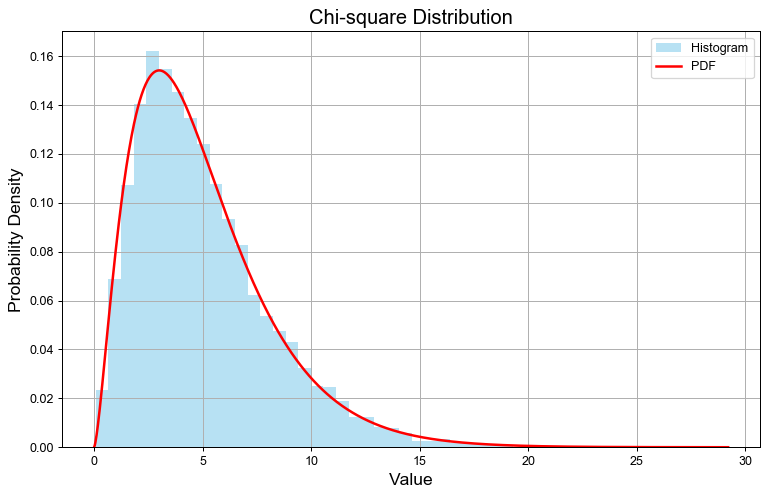

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 设置随机种子便于复现
np.random.seed(42)

# 定义卡方分布的自由度
df = 5

# 生成卡方分布数据
num_samples = 10000
data = np.random.chisquare(df, size=num_samples)

# 计算卡方分布的概率密度函数（PDF）用于绘图
x = np.linspace(0, np.max(data), 1000)
pdf = stats.chi2.pdf(x, df)

# 绘制直方图和理论概率密度曲线
plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, density=True, alpha=0.6, color='skyblue', label="Histogram")
plt.plot(x, pdf, 'r-', lw=2, label="PDF")

# 设置标题和坐标轴标签
plt.title("Chi-square Distribution", fontsize=16)
plt.xlabel("Value", fontsize=14)
plt.ylabel("Probability Density", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_015.png)

1. **数据生成：**使用 `np.random.chisquare(df, size=num_samples)` 直接生成服从自由度 `df` 的卡方分布数据。
2. **理论PDF曲线：**利用 `scipy.stats.chi2.pdf(x, df)` 计算给定 `x` 区间内的卡方分布理论概率密度，并绘制与直方图比较，从而直观验证数据分布的特性。
3. **图形**：可以直观地看到卡方分布数据的分布情况，并验证其理论分布形状。

### 卡方检验与机器学习中的应用

在机器学习中，特征选择（Feature Selection）用于从大量特征中挑选出与目标变量关系紧密的变量，从而提高模型的准确性和运行效率。

对于分类问题，一种常用的方法是利用卡方检验来评估每个特征与目标变量之间的独立性，进而选出最具有判别能力的特征。

卡方检验的基本思想是对离散变量建立观察频率与期望频率的比较，进而计算卡方统计量，如果统计量显著偏离预期，则说明该特征与目标变量存在较强的相关性。

通常使用公式：


$$
\chi^2 = \sum_{i} \frac{(O_i - E_i)^2}{E_i}
$$


其中 $O_i$ 是观察频数，$E_i$ 是期望频数。该统计量服从卡方分布，其自由度由类别数决定。

#### 机器学习示例：使用Scikit-learn进行特征选择

下面通过一个具体例子说明如何使用Python中的Scikit-learn库来实现基于卡方分布的特征选择。假设我们有一个文本分类数据集，需要通过卡方检验选出最相关的词项作为特征。

In [3]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# 构造一个简单的文本数据集和标签 
data = {
    "text": [
        "我喜欢这本书",
        "这本书非常好",
        "我不喜欢这本书",
        "这本书太差了",
        "非常精彩的故事",
        "情节非常无聊",
        "我强烈推荐这本书",
        "不推荐这本书",
        "故事情节引人入胜",
        "内容非常糟糕"
    ],
    "label": [1, 1, 0, 0, 1, 0, 1, 0, 1, 0]  # 1 表示正面，0 表示负面
}

df = pd.DataFrame(data)

# 对文本进行向量化，统计词频
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["text"])
y = df["label"]

# 使用卡方检验进行特征选择，选择排名前5的特征
chi2_selector = SelectKBest(chi2, k=5)
X_kbest = chi2_selector.fit_transform(X, y)

# 查看选择的特征名称
selected_indices = chi2_selector.get_support(indices=True)
selected_features = [vectorizer.get_feature_names_out()[i] for i in selected_indices]
print("Selected Features:", selected_features)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_kbest, y, test_size=0.3, random_state=42)

# 训练朴素贝叶斯分类器
clf = MultinomialNB()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Selected Features: ['我强烈推荐这本书', '故事情节引人入胜', '这本书太差了', '这本书非常好', '非常精彩的故事']
Accuracy: 0.3333333333333333


1. **数据预处理：**利用 `CountVectorizer` 将中文文本转换为词频矩阵，其中每一列代表一个词语。
2. **特征选择：**使用 `SelectKBest` 和 `chi2` 进行卡方检验，筛选出与类别标签最相关的前5个特征。打印输出这些特征名称，直观展示卡方检验在特征选择中的作用。
3. **分类器训练：**划分数据集后，利用朴素贝叶斯分类器进行训练与测试，并输出模型准确率。该过程展示了如何利用卡方特征选择优化机器学习模型。

我们可以看到卡方检验如何在实际机器学习任务中用于特征选择，帮助提高模型预测效果。

## 进一步延伸与总结

#### 卡方分布在统计检验中的应用

卡方分布除了在机器学习中的特征选择应用外，还有许多其他经典应用，例如：

- **拟合优度检验**：当我们需要检验观察数据是否与某个预期分布相符时，可以计算卡方统计量，再根据卡方分布判断观察数据与理论分布之间是否存在显著差异。
- **独立性检验：**在分类数据分析中，卡方检验常被用于判断两个分类变量之间是否存在关联。例如，在市场调查中，我们可以使用卡方检验判断消费者性别与产品偏好之间是否相关。
- **方差分析中的应用：**卡方分布也出现在方差分析和样本方差估计中，例如可以利用样本方差与真实方差之间的关系构造统计量进行假设检验。

#### 数学与实际应用的桥梁

理解卡方分布不仅要求掌握其数学公式和性质，更需要了解实际应用场景中的意义。

正如前文所述：

- 卡方分布的非负性和右偏特点反映了数据中平方偏差的性质。
- 自由度的概念帮助我们理解在数据量大时分布的变化趋势。
- 利用卡方分布构造的统计量为许多假设检验提供了理论依据，确保了测试结果的科学性和准确性。

#### 如何更好地掌握卡方分布

为了更全面地掌握卡方分布，建议大家采取以下步骤：

1. **掌握基本定义和公式：**深入理解卡方分布的定义、PDF、CDF以及它的数学性质。熟悉伽马函数的概念及其在正则化常数中的作用。
2. **多做案例实践：**通过实际数据的分析，使用Python进行卡方分布的数据生成、可视化以及统计检验和特征选择实验，加深对理论知识的理解。使用不同自由度的数据，观察分布形态变化，理解自由度的影响。
3. **理论与实验相结合：**将直观理解与数学推导相结合，不仅学习公式的推导过程，还要通过实验结果验证和感知分布的实际效果。可以尝试修改自由度参数，绘制直方图和理论曲线对比，逐步提升对卡方分布直观理解的深度。
4. **关注实际应用：**阅读一些统计学及数据挖掘领域的实际案例，如医学统计、市场调查和机器学习中的特征选择，体会卡方分布在实际数据分析中的应用场景和意义。

### 总结

卡方分布作为一种通过标准正态分布平方和构造而来的分布，其核心特性在于：

- 只包含非负值，并且右偏；
- 自由度决定了分布的具体形态；
- 具有广泛的数学性质，如均值 $E[X]=k$、方差 $Var[X]=2k$ 以及矩生成函数等；
- 广泛应用于统计检验和机器学习算法中，如拟合优度检验、独立性检验和特征选择等。

本文从直观解释、公式推导、Python实现三个层面对卡方分布做了全面阐述，希望能够帮助大家对这一重要概率分布有系统、深入的了解。